# Data Visualization of Developer Survey

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook creates various visualizations from the developer survey data using SQLite database queries and Python plotting libraries.

## Setting Up the Database

First, I'll set up a SQLite database.

## Importing Libraries

I'll import the necessary libraries for database operations and visualization.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import numpy as np

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Loading Data into SQLite Database

Now I'll read the CSV file and create a SQLite database.

In [15]:
# Download the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Read the CSV file
df = pd.read_csv(url)

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (65437, 114)

First few rows:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [16]:
# Create SQLite database and insert data
conn = sqlite3.connect('survey-data.sqlite')

# Write dataframe to SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)

print("✅ Data successfully loaded into SQLite database")

✅ Data successfully loaded into SQLite database


## Verifying the Database

Let me verify the data was correctly loaded into the database.

In [17]:
# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)
print("Sample data from database:")
df_check

Sample data from database:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,None,None
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,None,None
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,None,None
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,None,None


In [18]:
# Count total rows
QUERY = "SELECT COUNT(*) as Total_Rows FROM main"
row_count = pd.read_sql_query(QUERY, conn)
print(f"Total rows in database: {row_count['Total_Rows'][0]}")

Total rows in database: 65437


## Visualizing Distribution of Data

### Histogram: Total Compensation

I'll create a histogram to show the distribution of total compensation.

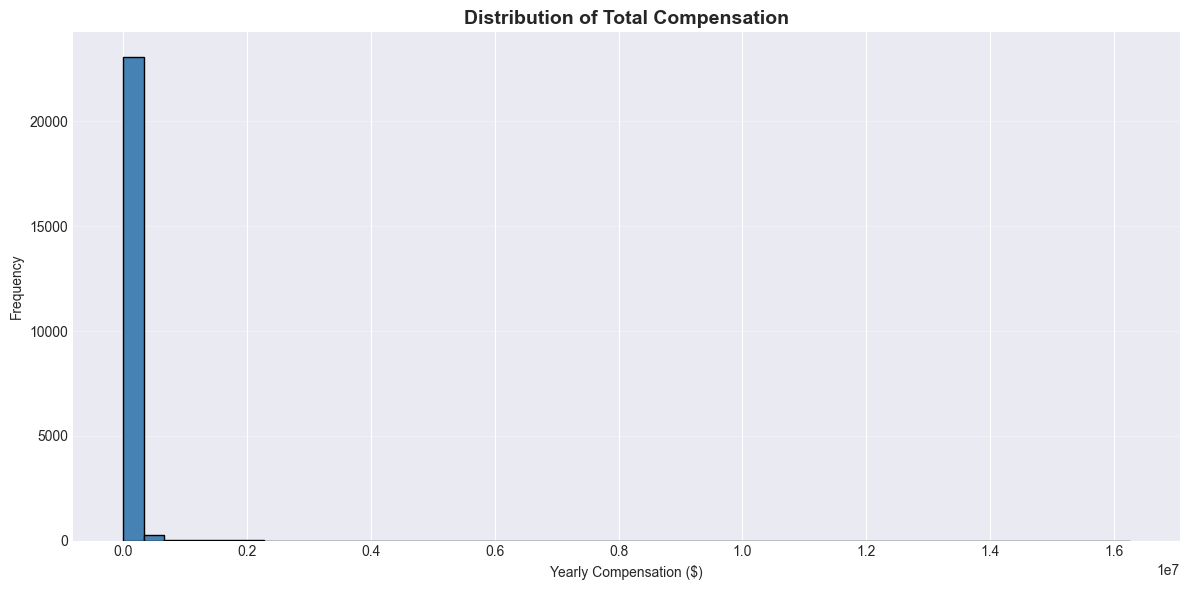

Number of compensation records: 23435


In [19]:
# Query compensation data
QUERY = """
SELECT ConvertedCompYearly 
FROM main 
WHERE ConvertedCompYearly IS NOT NULL
"""
comp_data = pd.read_sql_query(QUERY, conn)

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(comp_data['ConvertedCompYearly'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Total Compensation', fontsize=14, fontweight='bold')
plt.xlabel('Yearly Compensation ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of compensation records: {len(comp_data)}")

### Box Plot: Age Distribution

I'll create a box plot to visualize the age distribution.

Age distribution:
Age
18-24 years old       14098
25-34 years old       23911
35-44 years old       14942
45-54 years old        6249
55-64 years old        2575
65 years or older       772
Prefer not to say       322
Under 18 years old     2568
Name: count, dtype: int64


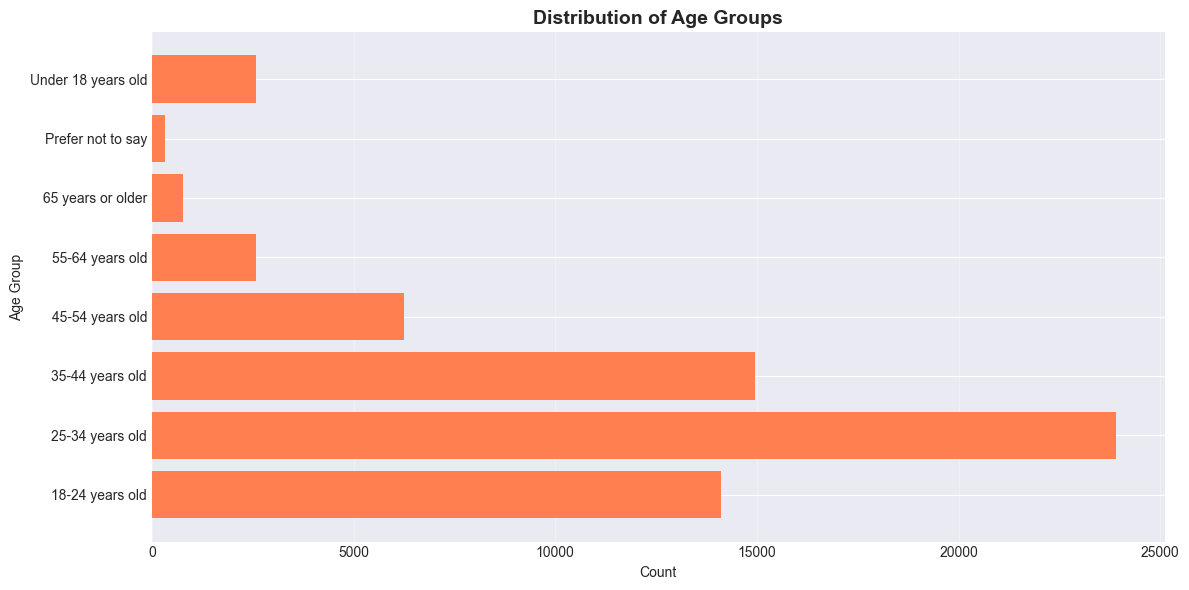

In [20]:
# Query age data
QUERY = """
SELECT Age 
FROM main 
WHERE Age IS NOT NULL
"""
age_data = pd.read_sql_query(QUERY, conn)

# Get counts by age group
age_counts = age_data['Age'].value_counts().sort_index()
print("Age distribution:")
print(age_counts)

# Create box plot (categorical)
plt.figure(figsize=(12, 6))
age_categories = age_data['Age'].unique()
plt.barh(range(len(age_counts)), age_counts.values, color='coral')
plt.yticks(range(len(age_counts)), age_counts.index)
plt.title('Distribution of Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Visualizing Relationships

### Scatter Plot: Age vs Work Experience

I'll create a scatter plot to explore the relationship between age and work experience.

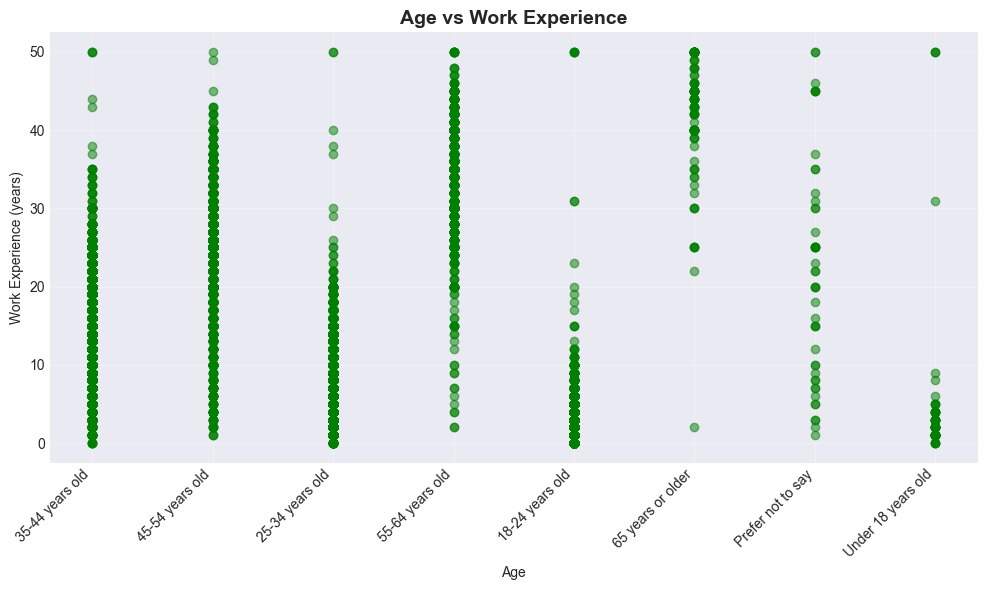

Number of records plotted: 29658


In [21]:
# Query age and work experience data
QUERY = """
SELECT Age, WorkExp 
FROM main 
WHERE Age IS NOT NULL AND WorkExp IS NOT NULL
"""
age_workexp = pd.read_sql_query(QUERY, conn)

# Convert to numeric for plotting
age_workexp['WorkExp'] = pd.to_numeric(age_workexp['WorkExp'], errors='coerce')
age_workexp = age_workexp.dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(age_workexp['Age'], age_workexp['WorkExp'], alpha=0.5, color='green')
plt.title('Age vs Work Experience', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Work Experience (years)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of records plotted: {len(age_workexp)}")

### Bubble Plot: TimeSearching vs Frustration

I'll create a bubble plot where the bubble size represents age.

In [22]:
# Query data for bubble plot
QUERY = """
SELECT TimeSearching, Frustration, Age 
FROM main 
WHERE TimeSearching IS NOT NULL 
  AND Frustration IS NOT NULL 
  AND Age IS NOT NULL
LIMIT 500
"""
bubble_data = pd.read_sql_query(QUERY, conn)

# Map categorical TimeSearching to numeric midpoints (minutes per day)
time_map = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}
bubble_data['TimeSearching'] = bubble_data['TimeSearching'].map(time_map)
bubble_data['Frustration'] = pd.to_numeric(bubble_data['Frustration'], errors='coerce')

# Map age to numeric for bubble size
age_map = {
    'Under 18 years old': 50,
    '18-24 years old': 100,
    '25-34 years old': 150,
    '35-44 years old': 200,
    '45-54 years old': 250,
    '55-64 years old': 300,
    '65 years or older': 350
}
bubble_data['BubbleSize'] = bubble_data['Age'].map(age_map).fillna(100)
bubble_data = bubble_data.dropna()

# Create bubble plot
plt.figure(figsize=(10, 6))
plt.scatter(bubble_data['TimeSearching'], bubble_data['Frustration'], 
           s=bubble_data['BubbleSize'], alpha=0.5, c='purple', edgecolors='black')
plt.title('Time Searching vs Frustration (bubble size = age)', fontsize=14, fontweight='bold')
plt.xlabel('Time Searching')
plt.ylabel('Frustration Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of records in bubble plot: {len(bubble_data)}")

## Visualizing Composition

### Pie Chart: Top 5 Databases Developers Want to Learn

I'll create a pie chart showing the top 5 databases people want to work with.

Top 5 Databases:
DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


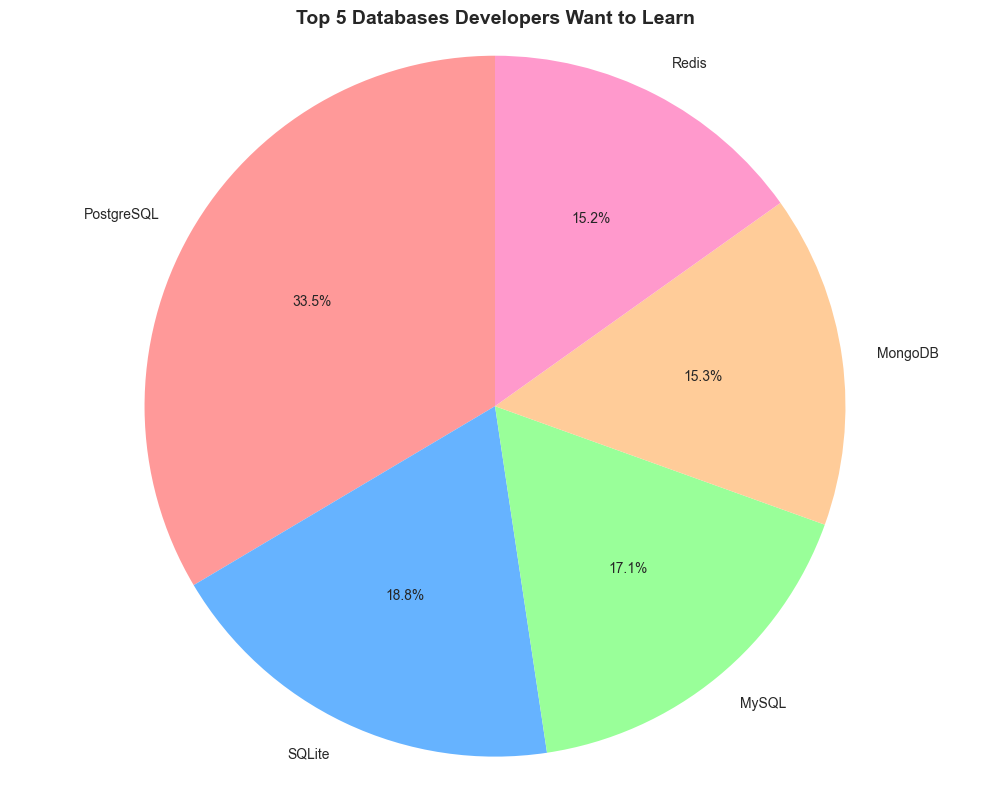

In [23]:
# Query database preferences
QUERY = """
SELECT DatabaseWantToWorkWith 
FROM main 
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
db_data = pd.read_sql_query(QUERY, conn)

# Split multiple databases and count
all_databases = db_data['DatabaseWantToWorkWith'].str.split(';').explode()
top_5_db = all_databases.value_counts().head(5)

print("Top 5 Databases:")
print(top_5_db)

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(top_5_db.values, labels=top_5_db.index, autopct='%1.1f%%', 
       startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#ff99cc'])
plt.title('Top 5 Databases Developers Want to Learn', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Stacked Chart: Time Metrics for Age Group 30-35

I'll create a stacked bar chart showing median time searching and answering for a specific age group.

In [24]:
# Query data for age group 25-34 (closest to 30-35)
QUERY = """
SELECT TimeSearching, TimeAnswering 
FROM main 
WHERE Age = '25-34 years old' 
  AND TimeSearching IS NOT NULL 
  AND TimeAnswering IS NOT NULL
"""
time_data = pd.read_sql_query(QUERY, conn)

# Map categorical time columns to numeric midpoints (minutes per day)
time_map = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}
time_data['TimeSearching'] = time_data['TimeSearching'].map(time_map)
time_data['TimeAnswering'] = time_data['TimeAnswering'].map(time_map)
time_data = time_data.dropna()

# Calculate medians
median_searching = time_data['TimeSearching'].median()
median_answering = time_data['TimeAnswering'].median()

print(f"Median Time Searching: {median_searching}")
print(f"Median Time Answering: {median_answering}")

# Create stacked bar chart
categories = ['Age 25-34']
searching = [median_searching]
answering = [median_answering]

plt.figure(figsize=(8, 6))
plt.bar(categories, searching, label='Time Searching', color='steelblue')
plt.bar(categories, answering, bottom=searching, label='Time Answering', color='coral')
plt.title('Median Time Searching and Answering (Age 25-34)', fontsize=14, fontweight='bold')
plt.ylabel('Time (median value)')
plt.legend()
plt.tight_layout()
plt.show()

## Visualizing Comparisons

### Line Chart: Average Compensation by Age (45-64)

I'll create a line chart showing how average compensation changes across age groups (45-64).

In [25]:
# Query median compensation by age
QUERY = """
SELECT Age, AVG(ConvertedCompYearly) as AvgComp
FROM main 
WHERE ConvertedCompYearly IS NOT NULL 
  AND Age IN ('45-54 years old', '55-64 years old')
GROUP BY Age
ORDER BY Age
"""
age_comp = pd.read_sql_query(QUERY, conn)

print("Average Compensation by Age Group:")
print(age_comp)

# Create line chart
plt.figure(figsize=(10, 6))
plt.plot(age_comp['Age'], age_comp['AvgComp'], marker='o', 
        linewidth=2, markersize=8, color='green')
plt.title('Average Compensation by Age Group (45-64)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Compensation ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Bar Chart: Main Branch Distribution

I'll create a horizontal bar chart showing the distribution of respondent types.

MainBranch Distribution:
                                          MainBranch  Count
0                     I am a developer by profession  50207
1  I am not primarily a developer, but I write co...   6511
2                              I am learning to code   3875
3                        I code primarily as a hobby   3334
4  I used to be a developer by profession, but no...   1510


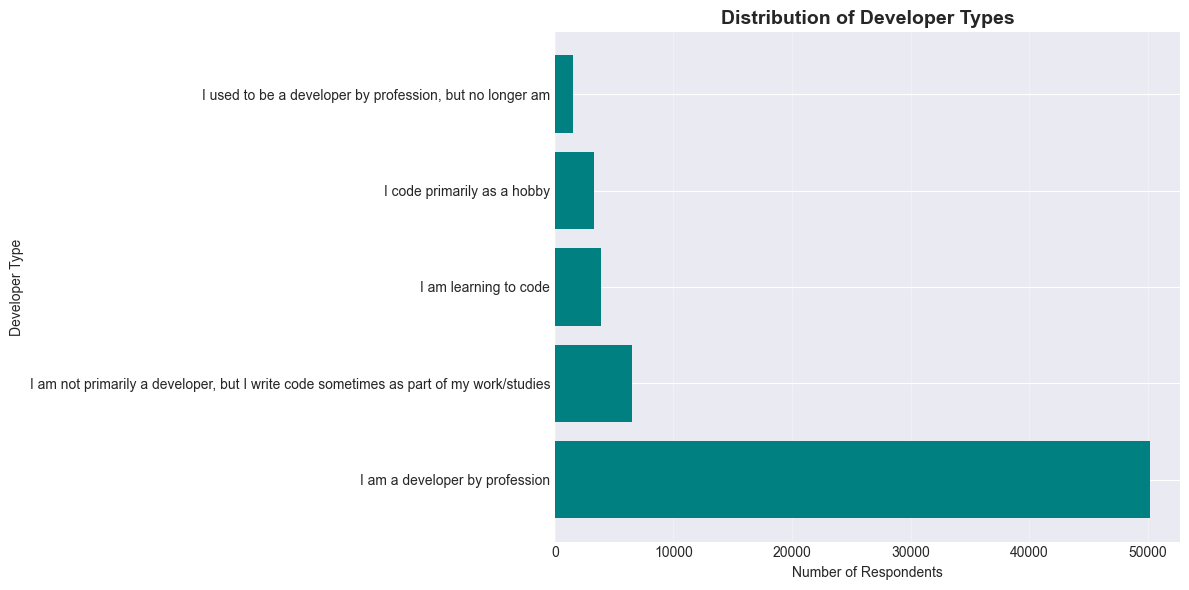

In [26]:
# Query MainBranch distribution
QUERY = """
SELECT MainBranch, COUNT(*) as Count
FROM main 
WHERE MainBranch IS NOT NULL
GROUP BY MainBranch
ORDER BY Count DESC
"""
branch_data = pd.read_sql_query(QUERY, conn)

print("MainBranch Distribution:")
print(branch_data)

# Create horizontal bar chart
plt.figure(figsize=(12, 6))
plt.barh(branch_data['MainBranch'], branch_data['Count'], color='teal')
plt.title('Distribution of Developer Types', fontsize=14, fontweight='bold')
plt.xlabel('Number of Respondents')
plt.ylabel('Developer Type')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Closing the Database Connection

Finally, I'll close the database connection.

In [27]:
# Close the connection
conn.close()
print("✅ Database connection closed")

✅ Database connection closed


## Summary

In this notebook, I created various visualizations to understand the developer survey data:

- **Distribution visualizations** - Histogram of compensation, bar chart of age groups
- **Relationship visualizations** - Scatter plot of age vs experience, bubble plot with three variables
- **Composition visualizations** - Pie chart of top databases, stacked bar chart of time metrics
- **Comparison visualizations** - Line chart of compensation trends, horizontal bar chart of developer types

These visualizations help reveal patterns in developer compensation, demographics, preferences, and behaviors across the survey population.